In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import linalg as la
from tqdm import tqdm
import pickle
import seaborn as sns
import cmasher as cmr
import kwant

from koala import plotting as pl

from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    spectral_function,
    _hopping_matrix,
    find_m_per_state,
    find_spin_per_state,
    spectral_path,
)

aps_figwidth = 3.375 * 2
aps_halfwidth = 3.375

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth

6.75

In [55]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)

In [56]:
data_name = "data/detailed_phase_diagram_20_V0"
lattice_name = "analysis/voronoi_20"
# load data
with open(data_name + ".pickle", "rb") as f:
    data = pickle.load(f)

# load lattice
with open(lattice_name + ".pickle", "rb") as f:
    lattice = pickle.load(f)

In [57]:
data["data"][0, 0].keys()

dict_keys(['hparam', 'energies', 'numerical_param'])

figure 1: a phase diagram

In [58]:
# process the data

fillings = data["filling"]
J_vals = data["J"]

all_avg_mags = np.zeros([len(fillings), len(J_vals)])

all_bond_diff_m = np.zeros([len(fillings), len(J_vals)])
all_bond_diff_n = np.zeros([len(fillings), len(J_vals)])

all_energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])
broadening = 0.1

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):
        current_data = data["params"][i, j]

        # calculate the average magnetization
        all_avg_mags[i, j] = np.mean(current_data["m"])

        all_energies[i, j] = data["data"][i, j]["energies"]

        # # calculate the density of states
        # all_dos_vals[i, j] = dos_at_fermi(
        #     all_energies[i, j], fermi_level(all_energies[i, j], filling), broadening
        # )

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        all_bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        all_bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()

100%|██████████| 41/41 [00:00<00:00, 541.40it/s]


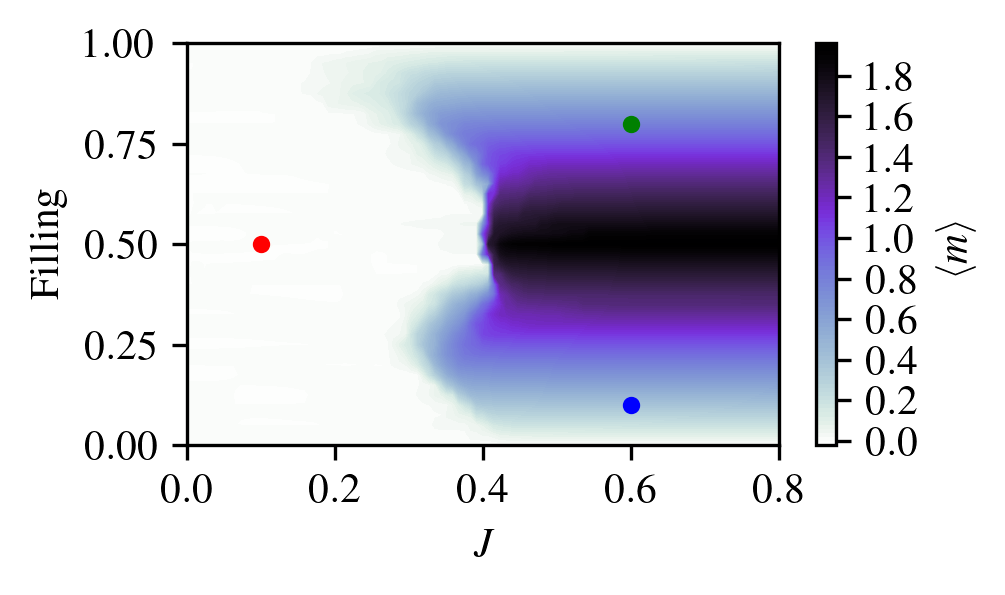

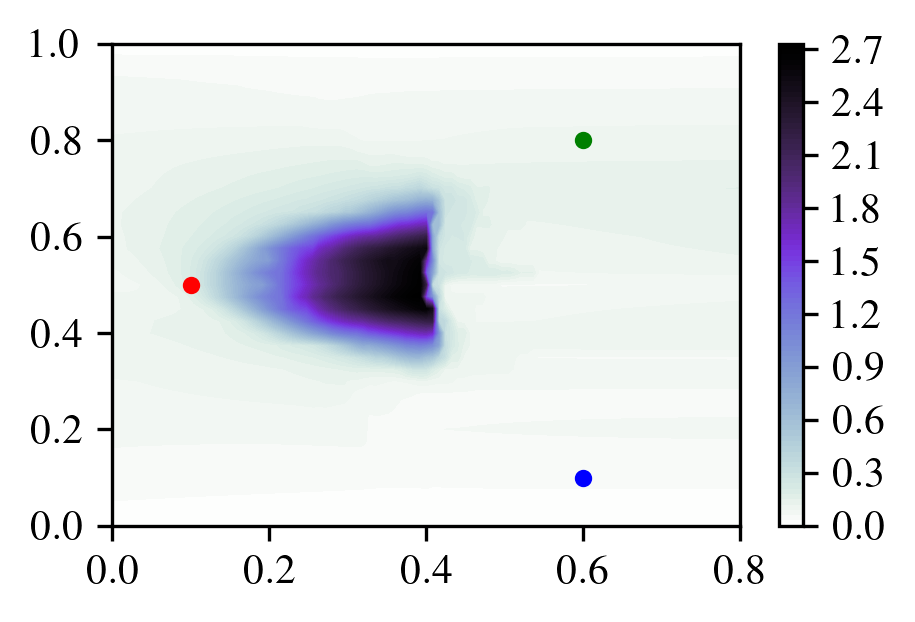

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(aps_halfwidth, aps_halfwidth / 1.618), dpi=300)

point_A = (0.1, 0.5)
point_B = (0.6, 0.1)
point_C = (0.6, 0.8)

points = [point_A, point_B, point_C]
argpoints = []
for i in range(3):
    point = points[i]
    arg_J = np.argmin(np.abs(J_vals - point[0]))
    arg_filling = np.argmin(np.abs(fillings - point[1]))
    argpoints.append((arg_J, arg_filling))
    point = (J_vals[arg_J], fillings[arg_filling])
    points[i] = point


# plot the average magnetization
im = ax.contourf(J_vals, fillings, all_avg_mags, levels=100, cmap=cmr.amethyst_r)

cbar = fig.colorbar(im, ax=ax)

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"Filling")
cbar.set_label(r"$\langle m \rangle$")

ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

plt.tight_layout()
plt.savefig("paper_figs/fig_1.pdf")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(aps_halfwidth, aps_halfwidth / 1.618), dpi=300)

# plot the n on bonds
im = ax.contourf(J_vals, fillings, all_bond_diff_n, levels=100, cmap=cmr.amethyst_r)
cbar = fig.colorbar(im, ax=ax)

ax.scatter([point_A[0]], [point_A[1]], color="red", s=10)
ax.scatter([point_B[0]], [point_B[1]], color="blue", s=10)
ax.scatter([point_C[0]], [point_C[1]], color="green", s=10)

In [ ]:
broadening = 0.2
nk = 100
n_energy = 200
n_path = 300
path = np.array([[1, 1], [1, 0], [0, 0], [0, 1], [1, 1]])

combined = []
spin_resolved = []
spin_up = []
spin_down = []
spectral_paths = []
spectral_paths_diffs = []
each_energies = []
each_fermi_level = []


for i in range(3):
    j_arg, fil_arg = argpoints[i]

    parameters_at_point = data["params"][fil_arg, j_arg]
    parameters_for_run = {
        "t1": parameters_at_point["t1"],
        "t2": parameters_at_point["t2"],
        "J": parameters_at_point["J"],
        "U": parameters_at_point["U"],
        "filling": parameters_at_point["filling"],
        "initial_m": parameters_at_point["m"],
        "initial_n": parameters_at_point["n"],
        "theta_offset": 0,
    }
    hamiltonian_at_point = alt_hamiltonian(
        lattice,
        parameters_for_run["t1"],
        parameters_for_run["t2"],
        parameters_for_run["J"],
        parameters_for_run["U"],
        parameters_for_run["initial_m"],
        parameters_for_run["initial_n"],
        parameters_for_run["theta_offset"],
    )

    energies_at_point, states_at_point = la.eigh(hamiltonian_at_point)

    fermi_energy_at_point = fermi_level(
        energies_at_point, parameters_for_run["filling"]
    )

    specs_at_point = [
        spectral_function(
            lattice,
            energies_at_point,
            states_at_point,
            fermi_energy_at_point,
            local_operator=np.eye(4)[i],
            eta=broadening,
            n_k=nk,
        )
        for i in range(4)
    ]

    spectral_path_at_point = spectral_path(
        lattice,
        energies_at_point,
        states_at_point,
        eta=0.1,
        n_k=n_path,
        n_energy=n_energy,
        local_operator=np.array([1, 1, 1, 1]),
        path=path,
    )
    spectral_path_at_point_diff = spectral_path(
        lattice,
        energies_at_point,
        states_at_point,
        eta=0.1,
        n_k=n_path,
        n_energy=n_energy,
        local_operator=np.array([1, 1, -1, -1]),
        path=path,
    )

    spectral_paths.append(spectral_path_at_point)
    spectral_paths_diffs.append(spectral_path_at_point_diff)

    combined.append(np.sum(specs_at_point, axis=0))
    spin_resolved.append(
        specs_at_point[0] + specs_at_point[1] - specs_at_point[2] - specs_at_point[3]
    )
    spin_up.append(specs_at_point[0] + specs_at_point[1])
    spin_down.append(specs_at_point[2] + specs_at_point[3])

    each_energies.append(energies_at_point)
    each_fermi_level.append(fermi_energy_at_point)

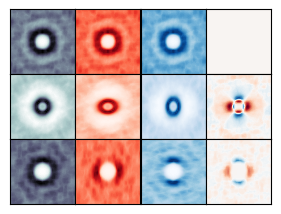

In [61]:
import cmasher as cmr


fig, ax = plt.subplots(
    3,
    4,
    figsize=(aps_halfwidth, (3 / 4) * aps_halfwidth),
    sharex=True,
    sharey=True,
)


fig.subplots_adjust(hspace=0.0, wspace=0.0)
for a in ax.flatten():
    a.set_aspect("equal")

max_comb, min_comb = np.max(combined), np.min(combined)
max_spin, min_spin = np.max(spin_resolved), np.min(spin_resolved)
min_down, max_down = np.min(spin_down), np.max(spin_down)
min_up, max_up = np.min(spin_up), np.max(spin_up)

k_vals = np.arange(-nk // 2, nk // 2) * 2 * np.pi
ks = np.array(np.meshgrid(k_vals, k_vals))

for i in range(3):
    ax[i, 0].contourf(
        ks[0],
        ks[1],
        combined[i],
        cmap="bone_r",
        origin="lower",
        levels=100,
        # vmin=min_comb,
        # vmax=max_comb,
    )
    ax[i, 1].contourf(
        ks[0],
        ks[1],
        spin_up[i],
        cmap="Reds",
        origin="lower",
        levels=100,
        # vmin=min_up,
        # vmax=max(spin_up[i]),
    )
    ax[i, 2].contourf(
        ks[0],
        ks[1],
        spin_down[i],
        cmap="Blues",
        origin="lower",
        levels=100,
        # vmin=min_down,
        # vmax=max_down,
    )
    ax[i, 3].contourf(
        ks[0],
        ks[1],
        spin_resolved[i],
        cmap="RdBu_r",
        origin="lower",
        levels=100,
        vmin=min_spin,
        vmax=max_spin,
    )

    # ax[0,i].set_xlabel(r"$k_x$")
    # ax[1,i].set_xlabel(r"$k_x$")
    # ax[0, 0].set_ylabel(r"$k_y$")
    # ax[1, 0].set_ylabel(r"$k_y$")
    # ax[0, i].set_xticks([])
    # ax[0, i].set_yticks([])

for a in ax.flatten():
    a.set_aspect("equal")
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(-np.pi * 50, np.pi * 50)
    a.set_ylim(-np.pi * 50, np.pi * 50)

plt.savefig("paper_figs/fig_2a.pdf")

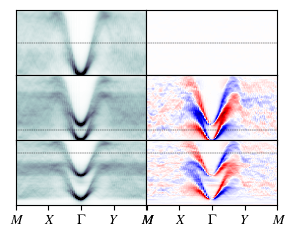

In [62]:
# plot the spectral paths

fig, axs2 = plt.subplots(
    3, 2, figsize=(aps_halfwidth, (3 / 4) * aps_halfwidth), sharex=True
)
fig.subplots_adjust(hspace=0.0, wspace=0.0)
extremum_diff = np.max(np.abs(spectral_paths_diffs))

for i in range(3):
    path = spectral_paths[i]

    path_diff = spectral_paths_diffs[i]
    fermi_line = each_fermi_level[i]

    energy_vals = np.linspace(
        np.min(each_energies[i]), np.max(each_energies[i]), n_energy
    )
    X, Y = np.meshgrid(np.arange(path.shape[0]), energy_vals)

    axs2[i, 0].axhline(fermi_line, color="black", linestyle="--", linewidth=0.3)
    axs2[i, 1].axhline(fermi_line, color="black", linestyle="--", linewidth=0.3)
    axs2[i, 0].pcolor(
        X, Y, path.real.T, cmap="bone_r", vmin=0, vmax=np.max(path.real) / 2
    )
    axs2[i, 1].pcolor(
        X, Y, path_diff.real.T, cmap="seismic", vmin=-extremum_diff, vmax=extremum_diff
    )
    axs2[i, 0].set_yticks([])
    axs2[i, 1].set_yticks([])

# set ticks to gamma x m y gamma
axs2[2, 1].set_xticks(np.array([0, 1, 2, 3, 4]) * path.shape[0] // 4)
axs2[2, 1].set_xticklabels([r"$M$", r"$X$", r"$\Gamma$", r"$Y$", r"$M$"])
plt.savefig("paper_figs/fig_2b.pdf")
plt.show()

In [ ]:
fig = plt.figure(
    figsize=(aps_figwidth, (3 / 4) * aps_halfwidth),
    dpi=300,
)

subfigs = fig.subfigures(1, 2, width_ratios=[1, 1.1], wspace=0)
axs0 = subfigs[0].subplots(3, 4, sharex=True, sharey=True)
axs1 = subfigs[1].subplots(3, 2)
subfigs[0].subplots_adjust(
    hspace=0.1, wspace=0.0, left=0.1, right=0.9, top=0.95, bottom=0.1
)
subfigs[1].subplots_adjust(
    hspace=0.1, wspace=0.0, left=0.1, right=0.9, top=0.95, bottom=0.1
)
# subfigs[0].set_facecolor('lightblue')
# subfigs[1].set_facecolor('yellow')
for a in axs0.flatten():
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(-np.pi * 50, np.pi * 50)
    a.set_ylim(-np.pi * 50, np.pi * 50)

for a in axs1.flatten():
    a.set_yticks([])

#################################
## plot the spectral functions ##
#################################


max_comb, min_comb = np.max(combined), np.min(combined)
max_spin, min_spin = np.max(spin_resolved), np.min(spin_resolved)
min_down, max_down = np.min(spin_down), np.max(spin_down)
min_up, max_up = np.min(spin_up), np.max(spin_up)

k_vals = np.arange(-nk // 2, nk // 2) * 2 * np.pi
ks = np.array(np.meshgrid(k_vals, k_vals))

for i in range(3):
    axs0[i, 0].contourf(
        ks[0],
        ks[1],
        combined[i],
        cmap="bone_r",
        origin="lower",
        levels=100,
        # vmin=min_comb,
        # vmax=max_comb,
    )
    axs0[i, 1].contourf(
        ks[0],
        ks[1],
        spin_up[i],
        cmap="Reds",
        origin="lower",
        levels=100,
        # vmin=min_up,
        # vmax=max(spin_up[i]),
    )
    axs0[i, 2].contourf(
        ks[0],
        ks[1],
        spin_down[i],
        cmap="Blues",
        origin="lower",
        levels=100,
        # vmin=min_down,
        # vmax=max_down,
    )
    axs0[i, 3].contourf(
        ks[0],
        ks[1],
        spin_resolved[i],
        cmap="RdBu_r",
        origin="lower",
        levels=100,
        vmin=min_spin,
        vmax=max_spin,
    )

    # ax[0,i].set_xlabel(r"$k_x$")
    # ax[1,i].set_xlabel(r"$k_x$")
    # ax[0, 0].set_ylabel(r"$k_y$")
    # ax[1, 0].set_ylabel(r"$k_y$")
    # ax[0, i].set_xticks([])
    # ax[0, i].set_yticks([])


#################################
######### plot the paths#########
#################################
extremum_diff = np.max(np.abs(spectral_paths_diffs)) / 1.5
for i in range(3):
    path = spectral_paths[i]

    path_diff = spectral_paths_diffs[i]
    fermi_line = each_fermi_level[i]

    energy_vals = np.linspace(
        np.min(each_energies[i]), np.max(each_energies[i]), n_energy
    )
    X, Y = np.meshgrid(np.arange(path.shape[0]), energy_vals)

    axs1[i, 0].axhline(fermi_line, color="black", linestyle="--", linewidth=0.3)
    axs1[i, 1].axhline(fermi_line, color="black", linestyle="--", linewidth=0.3)
    axs1[i, 0].pcolor(
        X, Y, path.real.T, cmap="bone_r", vmin=0, vmax=np.max(path.real) / 2
    )
    axs1[i, 1].pcolor(
        X, Y, path_diff.real.T, cmap="RdBu_r", vmin=-extremum_diff, vmax=extremum_diff
    )
    axs1[i, 0].set_yticks([])
    axs1[i, 1].set_yticks([])
    axs1[i, 0].set_xticks([])
    axs1[i, 1].set_xticks([])


axs1[2, 1].set_xticks(np.array([0, 1, 2, 3, 4]) * path.shape[0] // 4)
axs1[2, 1].set_xticklabels([r"$M$", r"$X$", r"$\Gamma$", r"$Y$", r"$M$"])
axs1[2, 0].set_xticks(np.array([0, 1, 2, 3, 4]) * path.shape[0] // 4)
axs1[2, 0].set_xticklabels([r"$M$", r"$X$", r"$\Gamma$", r"$Y$", r"$M$"])


plt.savefig("paper_figs/fig_2.pdf")

plt.show()